# Mueller Matrix Tissue Segmentation - 4-Class Transfer Learning

**Classes:**
- Class 0: Background
- Class 1: Tissue (general)
- Class 2: OS (specific structure within tissue)
- Class 3: Vaginal (specific structure within tissue)

**Before running:**
1. Update the `DATA_DIR` path in the Configuration cell
2. Adjust `BATCH_SIZE` based on your GPU memory
3. Run all cells in order

**Note:** The notebook will automatically check which samples have OS/Vaginal masks and print statistics.

## 1. Imports and Setup

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import torchvision.models as models
import numpy as np
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import json
import logging
import ssl
import warnings
import platform

warnings.filterwarnings('ignore')
ssl._create_default_https_context = ssl._create_unverified_context

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

print("Imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

C:\Users\user_picm\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports successful
PyTorch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA RTX 5000 Ada Generation Laptop GPU


## 2. Configuration

In [4]:
class Config:
    """Configuration - MODIFY THESE FOR YOUR SETUP"""

    # === PATHS ===
    DATA_DIR = Path("F:/MPL_Data/mmNoTissueFilter/TRIMMM")
    OUTPUT_DIR = Path("models")

    # === MODEL ===
    ENCODER_NAME = 'resnet34'
    USE_PRETRAINED = True

    # === TRAINING ===
    BATCH_SIZE = 8
    NUM_EPOCHS = 50
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-5
    PATIENCE = 15

    # === DATA ===
    TRAIN_RATIO = 0.70
    VAL_RATIO = 0.15
    TEST_RATIO = 0.15
    RANDOM_SEED = 42
    INPUT_SIZE = (512, 512)

    # === GPU/PERFORMANCE ===
    USE_GPU = True
    USE_MIXED_PRECISION = True
    NUM_WORKERS = 0
    PIN_MEMORY = True

    # === EXPORT ===
    EXPORT_ONNX = True


if Config.USE_GPU and torch.cuda.is_available():
    Config.DEVICE = torch.device('cuda')
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    Config.DEVICE = torch.device('cpu')
    Config.USE_MIXED_PRECISION = False
    Config.NUM_WORKERS = 0
    print("Using CPU")

print(f"Platform: {platform.system()}")
print(f"Data directory: {Config.DATA_DIR}")
print(f"Output directory: {Config.OUTPUT_DIR}")

Using GPU: NVIDIA RTX 5000 Ada Generation Laptop GPU
  Memory: 17.17 GB
Platform: Windows
Data directory: F:\MPL_Data\mmNoTissueFilter\TRIMMM
Output directory: models


## 3. Model Definition

In [5]:
class UNetWithPretrainedEncoder(nn.Module):
    """U-Net with pretrained encoder"""

    def __init__(self, encoder_name='resnet34', num_classes=2, pretrained=True):
        super().__init__()

        self.encoder_name = encoder_name
        self.num_classes = num_classes

        try:
            if encoder_name == 'resnet18':
                weights = models.ResNet18_Weights.IMAGENET1K_V1 if pretrained else None
                encoder = models.resnet18(weights=weights)
                encoder_channels = [64, 64, 128, 256, 512]
            elif encoder_name == 'resnet34':
                weights = models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
                encoder = models.resnet34(weights=weights)
                encoder_channels = [64, 64, 128, 256, 512]
            elif encoder_name == 'resnet50':
                weights = models.ResNet50_Weights.IMAGENET1K_V1 if pretrained else None
                encoder = models.resnet50(weights=weights)
                encoder_channels = [64, 256, 512, 1024, 2048]
            elif encoder_name == 'mobilenet_v2':
                weights = models.MobileNet_V2_Weights.IMAGENET1K_V1 if pretrained else None
                encoder = models.mobilenet_v2(weights=weights)
                encoder_channels = [16, 24, 32, 96, 1280]
            else:
                raise ValueError(f"Unsupported encoder: {encoder_name}")
        except Exception as e:
            print(f"Warning: {e}. Using random initialization.")
            pretrained = False
            if encoder_name == 'resnet34':
                encoder = models.resnet34(weights=None)
                encoder_channels = [64, 64, 128, 256, 512]

        if 'resnet' in encoder_name:
            self.encoder0 = nn.Sequential(encoder.conv1, encoder.bn1, encoder.relu)
            self.encoder1 = nn.Sequential(encoder.maxpool, encoder.layer1)
            self.encoder2 = encoder.layer2
            self.encoder3 = encoder.layer3
            self.encoder4 = encoder.layer4
        elif encoder_name == 'mobilenet_v2':
            features = encoder.features
            self.encoder0 = features[0:2]
            self.encoder1 = features[2:4]
            self.encoder2 = features[4:7]
            self.encoder3 = features[7:14]
            self.encoder4 = features[14:]

        self.enc_channels = encoder_channels

        self.decoder4 = self._decoder_block(encoder_channels[4] + encoder_channels[3], encoder_channels[3])
        self.decoder3 = self._decoder_block(encoder_channels[3] + encoder_channels[2], encoder_channels[2])
        self.decoder2 = self._decoder_block(encoder_channels[2] + encoder_channels[1], encoder_channels[1])
        self.decoder1 = self._decoder_block(encoder_channels[1] + encoder_channels[0], encoder_channels[0])
        self.decoder0 = self._decoder_block(encoder_channels[0], 64)
        self.final_conv = nn.Conv2d(64, num_classes, 1)

    def _decoder_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        enc0 = self.encoder0(x)
        enc1 = self.encoder1(enc0)
        enc2 = self.encoder2(enc1)
        enc3 = self.encoder3(enc2)
        enc4 = self.encoder4(enc3)

        dec4 = F.interpolate(enc4, scale_factor=2, mode='nearest')
        dec4 = self._match_size(dec4, enc3)
        dec4 = torch.cat([dec4, enc3], dim=1)
        dec4 = self.decoder4(dec4)

        dec3 = F.interpolate(dec4, scale_factor=2, mode='nearest')
        dec3 = self._match_size(dec3, enc2)
        dec3 = torch.cat([dec3, enc2], dim=1)
        dec3 = self.decoder3(dec3)

        dec2 = F.interpolate(dec3, scale_factor=2, mode='nearest')
        dec2 = self._match_size(dec2, enc1)
        dec2 = torch.cat([dec2, enc1], dim=1)
        dec2 = self.decoder2(dec2)

        dec1 = F.interpolate(dec2, scale_factor=2, mode='nearest')
        dec1 = self._match_size(dec1, enc0)
        dec1 = torch.cat([dec1, enc0], dim=1)
        dec1 = self.decoder1(dec1)

        dec0 = F.interpolate(dec1, scale_factor=4, mode='nearest')
        dec0 = self._match_size(dec0, x)
        dec0 = self.decoder0(dec0)

        return self.final_conv(dec0)

    def _match_size(self, x, target):
        if x.shape[2:] == target.shape[2:]:
            return x

        diff_h = x.shape[2] - target.shape[2]
        diff_w = x.shape[3] - target.shape[3]

        if diff_h > 0 or diff_w > 0:
            h_start = diff_h // 2
            w_start = diff_w // 2
            return x[:, :, h_start:h_start+target.shape[2], w_start:w_start+target.shape[3]]
        elif diff_h < 0 or diff_w < 0:
            pad_h = (-diff_h) // 2
            pad_w = (-diff_w) // 2
            return F.pad(x, (pad_w, -diff_w-pad_w, pad_h, -diff_h-pad_h))

        return x


print("Model defined")

Model defined


## 4. ONNX Export Function

In [6]:
def export_to_onnx(model, save_path: Path, input_size: Tuple[int, int] = (512, 512), num_classes: int = 2):
    """Export model to ONNX format"""
    model.eval()
    device = next(model.parameters()).device
    dummy_input = torch.randn(1, 3, input_size[0], input_size[1]).to(device)

    try:
        torch.onnx.export(
            model,
            dummy_input,
            save_path,
            export_params=True,
            opset_version=11,
            do_constant_folding=True,
            input_names=['input'],
            output_names=['output'],
            dynamic_axes={
                'input': {0: 'batch_size'},
                'output': {0: 'batch_size'}
            }
        )
        print(f"ONNX model exported to: {save_path}")
        return True
    except Exception as e:
        print(f"Warning: ONNX export failed: {e}")
        return False


print("ONNX export function defined")

ONNX export function defined


## 5. Data Loading Functions

In [7]:
def discover_samples(data_dir: Path) -> List[Dict]:
    """Discover samples in directory structure"""
    if not data_dir.exists():
        raise FileNotFoundError(f"Directory not found: {data_dir}")

    samples = []
    parent_dirs = [d for d in data_dir.iterdir() if d.is_dir() and not d.name.startswith('.')]
    
    print(f"Found {len(parent_dirs)} directories in {data_dir}")
    
    for parent_dir in parent_dirs:
        print(f"  Searching in: {parent_dir.name}")
        sample_dirs = [d for d in parent_dir.iterdir() if d.is_dir() and not d.name.startswith('.')]
        
        sample_groups = {}
        for sample_dir in sample_dirs:
            name = sample_dir.name
            base_name = name
            for suffix in ['_original', '_rot90', '_rot180', '_rot270', '_flip_h', '_flip_v']:
                base_name = base_name.replace(suffix, '')
            
            unique_name = f"{parent_dir.name}_{base_name}"
            
            if unique_name not in sample_groups:
                sample_groups[unique_name] = []
            sample_groups[unique_name].append(sample_dir)
        
        for unique_name, dirs in sample_groups.items():
            selected_dir = next((d for d in dirs if '_original' in d.name), dirs[0])
            npz_files = [f for f in selected_dir.glob("*.npz") if not f.name.startswith('.')]
            
            if npz_files:
                samples.append({
                    'sample_name': unique_name,
                    'parent_folder': parent_dir.name,
                    'sample_dir': selected_dir,
                    'npz_path': npz_files[0]
                })
                print(f"    Found: {selected_dir.name} -> {npz_files[0].name}")
    
    return samples


def extract_m11_and_mask(npz_path: Path) -> Optional[Tuple[np.ndarray, np.ndarray, Dict[str, bool]]]:
    """
    Extract M11 and combined 4-class mask from NPZ file.
    
    Class hierarchy:
    - 0: Background
    - 1: Tissue (general)
    - 2: OS (specific structure within tissue)
    - 3: Vaginal (specific structure within tissue)
    
    Priority: Vaginal > OS > Tissue > Background
    """
    try:
        with np.load(npz_path, allow_pickle=True) as data:
            # Extract M11
            m11 = None
            if 'nM11s' in data:
                m11 = np.array(data['nM11s'])
            elif 'M11s' in data:
                m11_raw = np.array(data['M11s'])
                m11_min, m11_max = m11_raw.min(), m11_raw.max()
                if m11_max > m11_min:
                    m11 = (m11_raw - m11_min) / (m11_max - m11_min)
                else:
                    m11 = np.zeros_like(m11_raw, dtype=np.float32)
            elif 'nM' in data:
                nM = np.array(data['nM'])
                if nM.ndim == 4 and nM.shape[-2:] == (4, 4):
                    m11 = nM[:, :, 0, 0]
                elif nM.ndim == 3 and nM.shape[-1] == 16:
                    m11 = nM[:, :, 0]

            if m11 is None or m11.ndim != 2:
                return None

            # Extract all available masks
            tissue_mask = None
            os_mask = None
            vaginal_mask = None

            # Check for tissue mask (try multiple keys)
            for key in ['tissue_mask', 'annotation_mask']:
                if key in data:
                    mask_data = data[key]
                    if isinstance(mask_data, np.ndarray) and mask_data.size > 0:
                        tissue_mask = np.array(mask_data) > 0
                        break

            # Check for OS mask
            if 'os_mask' in data:
                mask_data = data['os_mask']
                if isinstance(mask_data, np.ndarray) and mask_data.size > 0:
                    os_mask = np.array(mask_data) > 0

            # Check for vaginal mask
            if 'vaginal_mask' in data:
                mask_data = data['vaginal_mask']
                if isinstance(mask_data, np.ndarray) and mask_data.size > 0:
                    vaginal_mask = np.array(mask_data) > 0

            # Must have at least tissue mask
            if tissue_mask is None:
                return None

            # Verify shape compatibility
            if tissue_mask.shape != m11.shape:
                return None
            if os_mask is not None and os_mask.shape != m11.shape:
                return None
            if vaginal_mask is not None and vaginal_mask.shape != m11.shape:
                return None

            # Combine masks into 4-class mask with priority
            # Priority: Vaginal (3) > OS (2) > Tissue (1) > Background (0)
            combined_mask = np.zeros_like(tissue_mask, dtype=np.int64)
            combined_mask[tissue_mask] = 1  # Class 1: General tissue

            if os_mask is not None:
                combined_mask[os_mask] = 2  # Class 2: OS (overrides tissue)

            if vaginal_mask is not None:
                combined_mask[vaginal_mask] = 3  # Class 3: Vaginal (overrides os and tissue)

            # Track which masks were found
            mask_info = {
                'has_tissue': True,
                'has_os': os_mask is not None and os_mask.any(),
                'has_vaginal': vaginal_mask is not None and vaginal_mask.any()
            }

            return m11.astype(np.float32), combined_mask.astype(np.int64), mask_info

    except Exception as e:
        return None


def print_mask_statistics(samples: List[Dict]):
    """Print statistics about mask availability across samples"""
    print("\n" + "=" * 80)
    print("MASK AVAILABILITY STATISTICS")
    print("=" * 80)
    
    stats = {
        'total': len(samples),
        'has_os': 0,
        'has_vaginal': 0,
        'has_both': 0,
        'missing_os': [],
        'missing_vaginal': [],
        'has_only_tissue': []
    }
    
    for sample in tqdm(samples, desc="Checking masks"):
        try:
            with np.load(sample['npz_path'], allow_pickle=True) as data:
                has_os = 'os_mask' in data and np.array(data['os_mask']).any()
                has_vaginal = 'vaginal_mask' in data and np.array(data['vaginal_mask']).any()
                
                if has_os:
                    stats['has_os'] += 1
                else:
                    stats['missing_os'].append(sample['sample_name'])
                
                if has_vaginal:
                    stats['has_vaginal'] += 1
                else:
                    stats['missing_vaginal'].append(sample['sample_name'])
                
                if has_os and has_vaginal:
                    stats['has_both'] += 1
                
                if not has_os and not has_vaginal:
                    stats['has_only_tissue'].append(sample['sample_name'])
        except:
            continue
    
    print(f"\nTotal samples: {stats['total']}")
    print(f"Samples with OS mask: {stats['has_os']} ({stats['has_os']/stats['total']*100:.1f}%)")
    print(f"Samples with Vaginal mask: {stats['has_vaginal']} ({stats['has_vaginal']/stats['total']*100:.1f}%)")
    print(f"Samples with both OS and Vaginal: {stats['has_both']} ({stats['has_both']/stats['total']*100:.1f}%)")
    print(f"Samples with only Tissue (no OS/Vaginal): {len(stats['has_only_tissue'])} ({len(stats['has_only_tissue'])/stats['total']*100:.1f}%)")
    
    if stats['missing_os']:
        print(f"\nWarning: Samples missing OS mask ({len(stats['missing_os'])}):")
        for name in stats['missing_os'][:10]:
            print(f"  - {name}")
        if len(stats['missing_os']) > 10:
            print(f"  ... and {len(stats['missing_os']) - 10} more")
    
    if stats['missing_vaginal']:
        print(f"\nWarning: Samples missing Vaginal mask ({len(stats['missing_vaginal'])}):")
        for name in stats['missing_vaginal'][:10]:
            print(f"  - {name}")
        if len(stats['missing_vaginal']) > 10:
            print(f"  ... and {len(stats['missing_vaginal']) - 10} more")
    
    if stats['has_only_tissue']:
        print(f"\nInfo: Samples with only Tissue mask ({len(stats['has_only_tissue'])}):")
        for name in stats['has_only_tissue'][:10]:
            print(f"  - {name}")
        if len(stats['has_only_tissue']) > 10:
            print(f"  ... and {len(stats['has_only_tissue']) - 10} more")
    
    print("=" * 80 + "\n")
    
    return stats


print("Data functions defined (4-class segmentation: Background, Tissue, OS, Vaginal)")

Data functions defined (4-class segmentation: Background, Tissue, OS, Vaginal)


## 6. Dataset Class

In [8]:
class M11SegmentationDataset(Dataset):
    def __init__(self, sample_paths: List[Path], input_size: Optional[Tuple[int, int]] = None,
                 augment: bool = False, normalize: bool = True):
        self.sample_paths = sample_paths
        self.input_size = input_size
        self.augment = augment
        self.normalize = normalize

        self.samples = []
        for path in tqdm(sample_paths, desc="Loading data"):
            data = extract_m11_and_mask(path)
            if data is not None:
                m11, mask, mask_info = data
                self.samples.append((path, (m11, mask), mask_info))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, (m11, mask), mask_info = self.samples[idx]

        if self.input_size is not None:
            m11 = self._resize(m11, self.input_size, is_mask=False)
            mask = self._resize(mask, self.input_size, is_mask=True)

        if self.augment:
            m11, mask = self._augment(m11, mask)

        m11_rgb = np.stack([m11, m11, m11], axis=0)

        if self.normalize:
            mean = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(3, 1, 1)
            std = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(3, 1, 1)
            m11_rgb = (m11_rgb - mean) / std

        return torch.from_numpy(m11_rgb).float(), torch.from_numpy(mask).long()

    def _resize(self, img, size, is_mask=False):
        img_torch = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0)
        mode = 'nearest' if is_mask else 'bilinear'
        resized = F.interpolate(img_torch, size=size, mode=mode, align_corners=None if is_mask else True)
        return resized.squeeze().numpy().astype(np.int64 if is_mask else np.float32)

    def _augment(self, m11, mask):
        # Random horizontal flip
        if np.random.rand() > 0.5:
            m11 = np.fliplr(m11).copy()
            mask = np.fliplr(mask).copy()
        
        # Random vertical flip
        if np.random.rand() > 0.5:
            m11 = np.flipud(m11).copy()
            mask = np.flipud(mask).copy()
        
        # Random rotation (0, 90, 180, 270 degrees)
        k = np.random.randint(0, 4)
        if k > 0:
            m11 = np.rot90(m11, k).copy()
            mask = np.rot90(mask, k).copy()
        
        return m11, mask


print("Dataset class defined")

Dataset class defined


## 7. Loss Functions

In [9]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, predictions, targets):
        probs = F.softmax(predictions, dim=1)
        num_classes = predictions.shape[1]
        targets_one_hot = F.one_hot(targets, num_classes).permute(0, 3, 1, 2).float()

        intersection = (probs * targets_one_hot).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + targets_one_hot.sum(dim=(2, 3))
        dice = (2. * intersection + self.smooth) / (union + self.smooth)

        return 1 - dice.mean()


class CombinedLoss(nn.Module):
    def __init__(self, weight_ce=0.5, weight_dice=0.5):
        super().__init__()
        self.weight_ce = weight_ce
        self.weight_dice = weight_dice
        self.ce = nn.CrossEntropyLoss()
        self.dice = DiceLoss()

    def forward(self, predictions, targets):
        return self.weight_ce * self.ce(predictions, targets) + self.weight_dice * self.dice(predictions, targets)


print("Loss functions defined")

Loss functions defined


## 8. Training Functions

In [10]:
def train_epoch(model, dataloader, criterion, optimizer, device, scaler=None, use_amp=False):
    model.train()
    total_loss = 0

    pbar = tqdm(dataloader, desc="Training")
    for images, masks in pbar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_amp and scaler is not None:
            with autocast():
                outputs = model(images)
                if outputs.shape[-2:] != masks.shape[-2:]:
                    outputs = F.interpolate(outputs, size=masks.shape[-2:], mode='nearest')
                loss = criterion(outputs, masks)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            if outputs.shape[-2:] != masks.shape[-2:]:
                outputs = F.interpolate(outputs, size=masks.shape[-2:], mode='nearest')
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(dataloader)


def validate_epoch(model, dataloader, criterion, device, use_amp=False):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Validation")
        for images, masks in pbar:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            if use_amp:
                with autocast():
                    outputs = model(images)
                    if outputs.shape[-2:] != masks.shape[-2:]:
                        outputs = F.interpolate(outputs, size=masks.shape[-2:], mode='nearest')
                    loss = criterion(outputs, masks)
            else:
                outputs = model(images)
                if outputs.shape[-2:] != masks.shape[-2:]:
                    outputs = F.interpolate(outputs, size=masks.shape[-2:], mode='nearest')
                loss = criterion(outputs, masks)

            preds = torch.argmax(outputs, dim=1)
            total_loss += loss.item()
            correct += (preds == masks).sum().item()
            total += masks.numel()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    return total_loss / len(dataloader), correct / total


print("Training functions defined")

Training functions defined


## 9. Load and Split Data

In [11]:
torch.manual_seed(Config.RANDOM_SEED)
np.random.seed(Config.RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(Config.RANDOM_SEED)

Config.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Looking for data in: {Config.DATA_DIR}\n")
samples = discover_samples(Config.DATA_DIR)
print(f"\nFound {len(samples)} samples")

if len(samples) == 0:
    raise ValueError("No samples found! Check your DATA_DIR path.")

# Print mask availability statistics
mask_stats = print_mask_statistics(samples)

# ============================================================================
# ISOLATE SPECIFIC SAMPLES FOR SEPARATE TESTING
# ============================================================================
print("\n" + "=" * 80)
print("ISOLATING SAMPLES FOR SEPARATE TESTING")
print("=" * 80)

# Define samples to isolate (exclude from train/val/test)
isolated_sample_names = [
    'Day6_mm_results_Day6E_4B_S2',
    'Day6_mm_results_day6_3',
    'Day0_mm_results_Day0G_7B_S3',
    'Day0_mm_results_Day0H_3B_S6'
]

# Separate isolated samples from the rest
isolated_samples = []
training_samples = []

for sample in samples:
    if sample['sample_name'] in isolated_sample_names:
        isolated_samples.append(sample)
        print(f"  ISOLATED: {sample['sample_name']}")
    else:
        training_samples.append(sample)

print(f"\nTotal samples: {len(samples)}")
print(f"Isolated samples: {len(isolated_samples)}")
print(f"Samples for train/val/test: {len(training_samples)}")

if len(isolated_samples) < len(isolated_sample_names):
    missing = set(isolated_sample_names) - {s['sample_name'] for s in isolated_samples}
    print(f"\nWarning: Some requested samples were not found: {missing}")

print("=" * 80 + "\n")
# ============================================================================

train_samples, temp = train_test_split(training_samples, test_size=Config.VAL_RATIO + Config.TEST_RATIO,
                                       random_state=Config.RANDOM_SEED)
val_samples, test_samples = train_test_split(temp, test_size=Config.TEST_RATIO / (Config.VAL_RATIO + Config.TEST_RATIO),
                                             random_state=Config.RANDOM_SEED)

print(f"Split: Train={len(train_samples)}, Val={len(val_samples)}, Test={len(test_samples)}, Isolated={len(isolated_samples)}")

split_info = {
    'train': [{'name': s['sample_name'], 'path': str(s['npz_path'])} for s in train_samples],
    'val': [{'name': s['sample_name'], 'path': str(s['npz_path'])} for s in val_samples],
    'test': [{'name': s['sample_name'], 'path': str(s['npz_path'])} for s in test_samples],
    'isolated': [{'name': s['sample_name'], 'path': str(s['npz_path'])} for s in isolated_samples],
    'mask_statistics': mask_stats
}
with open(Config.OUTPUT_DIR / 'data_split.json', 'w') as f:
    json.dump(split_info, f, indent=2)
print(f"Split information saved to: {Config.OUTPUT_DIR / 'data_split.json'}")

train_dataset = M11SegmentationDataset([s['npz_path'] for s in train_samples], input_size=Config.INPUT_SIZE,
                                       augment=True)
val_dataset = M11SegmentationDataset([s['npz_path'] for s in val_samples], input_size=Config.INPUT_SIZE, augment=False)
test_dataset = M11SegmentationDataset([s['npz_path'] for s in test_samples], input_size=Config.INPUT_SIZE,
                                      augment=False)

print(f"Loaded {len(train_dataset)} training samples")

train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=Config.NUM_WORKERS,
                          pin_memory=Config.PIN_MEMORY)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS,
                        pin_memory=Config.PIN_MEMORY)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS,
                         pin_memory=Config.PIN_MEMORY)

all_classes = set()
for _, mask in train_dataset:
    all_classes.update(mask.unique().numpy())
num_classes = len(all_classes)

print(f"\n{'='*80}")
print(f"CLASS INFORMATION")
print(f"{'='*80}")
print(f"Detected {num_classes} classes in training data: {sorted(all_classes)}")
print(f"  Class 0: Background")
print(f"  Class 1: Tissue")
if 2 in all_classes:
    print(f"  Class 2: OS")
if 3 in all_classes:
    print(f"  Class 3: Vaginal")
print(f"{'='*80}\n")

Looking for data in: F:\MPL_Data\mmNoTissueFilter\TRIMMM

Found 7 directories in F:\MPL_Data\mmNoTissueFilter\TRIMMM
  Searching in: Day6
    Found: mm_results_day6_2 -> TRIMMM.npz
    Found: mm_results_day6_3 -> TRIMMM.npz
    Found: mm_results_day6_4 -> TRIMMM.npz
    Found: mm_results_day6_1 -> TRIMMM.npz
    Found: mm_results_Day6D_7B_S3 -> TRIMMM.npz
    Found: mm_results_Day6D_8B_S3 -> TRIMMM.npz
    Found: mm_results_Day6D_9B_S1 -> TRIMMM.npz
    Found: mm_results_Day6E_4B_S2 -> TRIMMM.npz
    Found: mm_results_Day6E_5B_S2 -> TRIMMM.npz
  Searching in: Day14
    Found: mm_results_D14D_S6A_3 -> TRIMMM.npz
    Found: mm_results_D14D_S8A_3 -> TRIMMM.npz
    Found: mm_results_Day14D_5A_3 -> TRIMMM.npz
    Found: mm_results_D14D_S5A_3 -> TRIMMM.npz
    Found: mm_results_D14C_S6A_3 -> TRIMMM.npz
    Found: mm_results_D14C_S8A_3 -> TRIMMM.npz
    Found: mm_results_D14c_S4A_5 -> TRIMMM.npz
  Searching in: Day0
    Found: mm_results_Day0F_6B_S4 -> TRIMMM.npz
    Found: mm_results_Day0F_7

Checking masks: 100%|██████████| 74/74 [00:01<00:00, 51.79it/s]



Total samples: 74
Samples with OS mask: 74 (100.0%)
Samples with Vaginal mask: 28 (37.8%)
Samples with both OS and Vaginal: 28 (37.8%)
Samples with only Tissue (no OS/Vaginal): 0 (0.0%)

  - Day6_mm_results_Day6D_8B_S3
  - Day6_mm_results_Day6D_9B_S1
  - Day6_mm_results_Day6E_5B_S2
  - Day14_mm_results_D14D_S8A_3
  - Day14_mm_results_D14C_S8A_3
  - Day0_mm_results_Day0F_6B_S4
  - Day0_mm_results_Day0F_7B_S2
  - Day0_mm_results_Day0F_5B_S2
  - Day0_mm_results_Day0G_9B_S4
  - Day0_mm_results_Day0H_4B_S5
  ... and 36 more


ISOLATING SAMPLES FOR SEPARATE TESTING
  ISOLATED: Day6_mm_results_day6_3
  ISOLATED: Day6_mm_results_Day6E_4B_S2
  ISOLATED: Day0_mm_results_Day0G_7B_S3
  ISOLATED: Day0_mm_results_Day0H_3B_S6

Total samples: 74
Isolated samples: 4
Samples for train/val/test: 70

Split: Train=49, Val=10, Test=11, Isolated=4
Split information saved to: models\data_split.json


Loading data: 100%|██████████| 11/11 [00:00<00:00, 11.97it/s]


Loaded 49 training samples

CLASS INFORMATION
Detected 4 classes in training data: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  Class 0: Background
  Class 1: Tissue
  Class 2: OS
  Class 3: Vaginal



## 10. Create Model

In [13]:
model = UNetWithPretrainedEncoder(
    encoder_name=Config.ENCODER_NAME,
    num_classes=num_classes,
    pretrained=Config.USE_PRETRAINED
).to(Config.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model created with {total_params:,} parameters")

Model created with 24,569,284 parameters


## 11. Setup Training

In [14]:
criterion = CombinedLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=Config.LEARNING_RATE, weight_decay=Config.WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5, verbose=True)
scaler = GradScaler() if Config.USE_MIXED_PRECISION else None

print("Training setup complete")
print(f"  Optimizer: AdamW (lr={Config.LEARNING_RATE})")
print(f"  Loss: Combined CE + Dice")
print(f"  Mixed precision: {Config.USE_MIXED_PRECISION}")

Training setup complete
  Optimizer: AdamW (lr=0.0001)
  Loss: Combined CE + Dice
  Mixed precision: True


## 12. Train Model

In [ ]:
best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'lr': []}

print("=" * 80)
print("STARTING TRAINING")
print("=" * 80)

for epoch in range(Config.NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{Config.NUM_EPOCHS} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    train_loss = train_epoch(model, train_loader, criterion, optimizer, Config.DEVICE, scaler,
                             Config.USE_MIXED_PRECISION)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, Config.DEVICE, Config.USE_MIXED_PRECISION)
    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    history['train_loss'].append(float(train_loss))
    history['val_loss'].append(float(val_loss))
    history['val_acc'].append(float(val_acc))
    history['lr'].append(float(optimizer.param_groups[0]['lr']))

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        pth_path = Config.OUTPUT_DIR / 'best_model.pth'
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
            'config': {
                'encoder_name': Config.ENCODER_NAME,
                'num_classes': num_classes,
                'input_size': Config.INPUT_SIZE
            }
        }, pth_path)
        print(f"Saved PyTorch model: {pth_path}")

        if Config.EXPORT_ONNX:
            onnx_path = Config.OUTPUT_DIR / 'best_model.onnx'
            export_to_onnx(model, onnx_path, Config.INPUT_SIZE, num_classes)
    else:
        patience_counter += 1

    if patience_counter >= Config.PATIENCE:
        print(f"Early stopping at epoch {epoch + 1}")
        break

with open(Config.OUTPUT_DIR / 'history.json', 'w') as f:
    json.dump(history, f, indent=2)

print("\n" + "=" * 80)
print("TRAINING COMPLETE!")
print("=" * 80)
print(f"\nModels saved in: {Config.OUTPUT_DIR}/")
print(f"  - best_model.pth (PyTorch)")
if Config.EXPORT_ONNX:
    print(f"  - best_model.onnx (ONNX)")

STARTING TRAINING

Epoch 1/50 | LR: 1.00e-04


Validation: 100%|██████████| 2/2 [00:00<00:00, 12.27it/s, loss=1.1006]


Train Loss: 0.9851 | Val Loss: 1.1056 | Val Acc: 0.0222
Saved PyTorch model: models\best_model.pth
ONNX model exported to: models\best_model.onnx

Epoch 2/50 | LR: 1.00e-04


Validation: 100%|██████████| 2/2 [00:00<00:00, 16.98it/s, loss=1.0782]


Train Loss: 0.8282 | Val Loss: 1.0799 | Val Acc: 0.2501
Saved PyTorch model: models\best_model.pth
ONNX model exported to: models\best_model.onnx

Epoch 3/50 | LR: 1.00e-04


...

Validation: 100%|██████████| 2/2 [00:00<00:00, 16.52it/s, loss=0.6851]


Train Loss: 0.6397 | Val Loss: 0.6599 | Val Acc: 0.7759
Saved PyTorch model: models\best_model.pth
ONNX model exported to: models\best_model.onnx

Epoch 6/50 | LR: 1.00e-04


Validation: 100%|██████████| 2/2 [00:00<00:00, 16.21it/s, loss=0.6667]


Train Loss: 0.5934 | Val Loss: 0.6066 | Val Acc: 0.7962
Saved PyTorch model: models\best_model.pth
ONNX model exported to: models\best_model.onnx

Epoch 7/50 | LR: 1.00e-04


Validation:   0%|          | 0/2 [00:00<?, ?it/s]

## 13. Evaluate on Test Set

In [15]:
print("Evaluating on test set...")
checkpoint = torch.load(Config.OUTPUT_DIR / 'best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])

test_loss, test_acc = validate_epoch(model, test_loader, criterion, Config.DEVICE, Config.USE_MIXED_PRECISION)

print(f"\nTest Results:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)")

with open(Config.OUTPUT_DIR / 'test_results.json', 'w') as f:
    json.dump({'test_loss': float(test_loss), 'test_acc': float(test_acc)}, f, indent=2)

print(f"\nAll results saved to: {Config.OUTPUT_DIR}")

Evaluating on test set...


Validation: 100%|██████████| 1/1 [00:00<00:00,  8.14it/s, loss=0.5255]


Test Results:
  Loss: 0.5255
  Accuracy: 0.8050 (80.50%)

All results saved to: models


## 14. Plot Training History

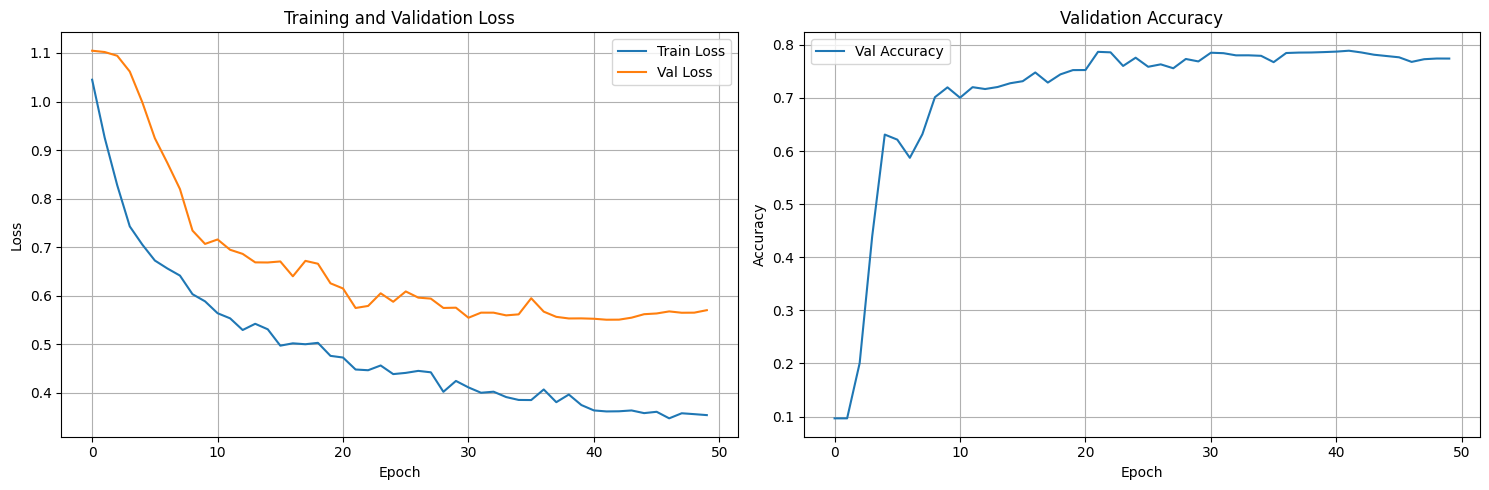

Training curves saved


In [16]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history['val_acc'], label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(Config.OUTPUT_DIR / 'training_curves.png', dpi=150)
plt.show()

print("Training curves saved")

## Done!

Your trained models are saved in the `models/` directory:
- `best_model.pth` - PyTorch checkpoint
- `best_model.onnx` - ONNX format
- `data_split.json` - Train/val/test split information

**Use `run_trained_m11_transfer.ipynb` for inference on new samples.**

## 15. Visualize Test Sample with Class Masks

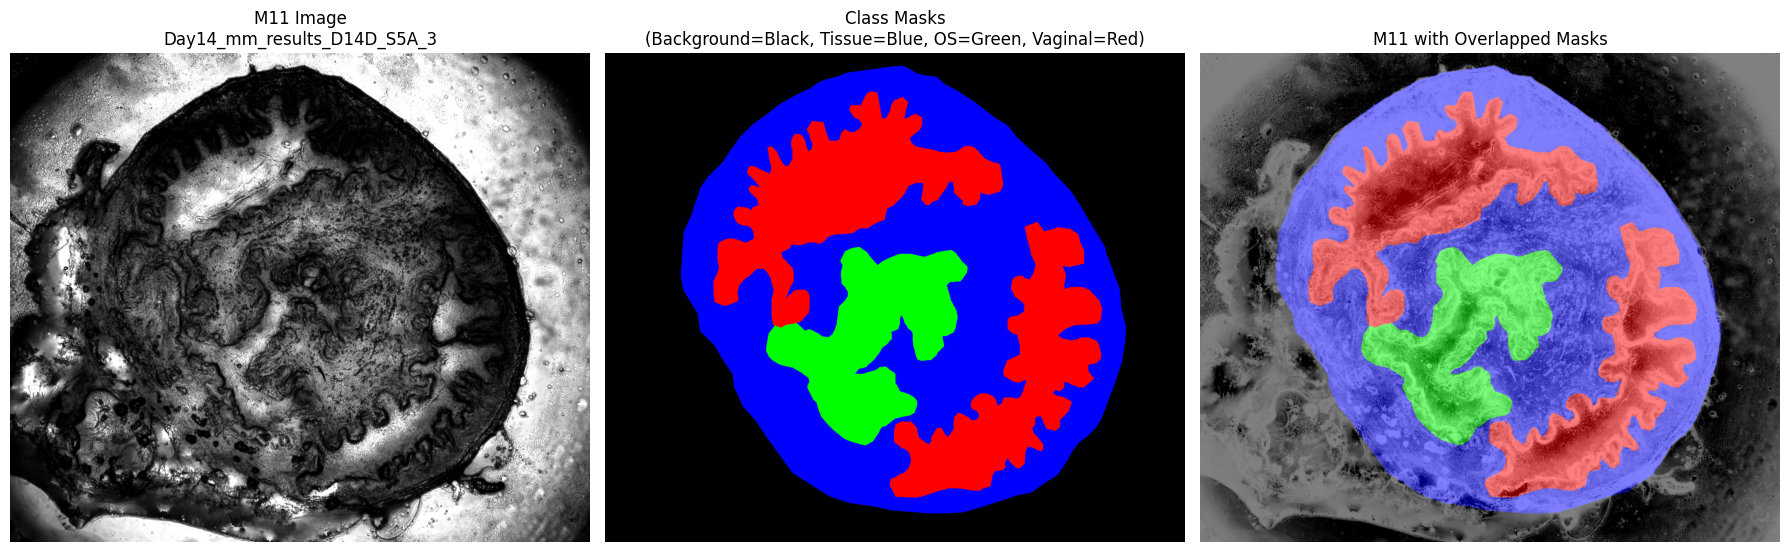


Sample: Day14_mm_results_D14D_S5A_3
Image shape: (1078, 1278)
Mask information:
  Has tissue mask: True
  Has OS mask: True
  Has vaginal mask: True

Class distribution:
  Class 0 (Background): 666813 pixels (48.40%)
  Class 1 (Tissue): 391339 pixels (28.41%)
  Class 2 (OS): 95150 pixels (6.91%)
  Class 3 (Vaginal): 224382 pixels (16.29%)

Visualization saved to: models\test_sample_visualization.png


In [17]:
# Get one sample from test dataset
sample_idx = 0
test_sample_path = test_samples[sample_idx]['npz_path']
sample_name = test_samples[sample_idx]['sample_name']

# Load the raw data
result = extract_m11_and_mask(test_sample_path)
if result is not None:
    m11, mask, mask_info = result
    
    # Create color map for classes
    # Class 0: Background - black
    # Class 1: Tissue - blue
    # Class 2: OS - green
    # Class 3: Vaginal - red
    colors = {
        0: [0, 0, 0],        # Background - black
        1: [0, 0, 255],      # Tissue - blue
        2: [0, 255, 0],      # OS - green
        3: [255, 0, 0]       # Vaginal - red
    }
    
    # Create RGB mask overlay
    mask_rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for class_id, color in colors.items():
        mask_rgb[mask == class_id] = color
    
    # Create figure
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Plot 1: M11 image
    axes[0].imshow(m11, cmap='gray')
    axes[0].set_title(f'M11 Image\n{sample_name}')
    axes[0].axis('off')
    
    # Plot 2: Mask overlay
    axes[1].imshow(mask_rgb)
    axes[1].set_title('Class Masks\n(Background=Black, Tissue=Blue, OS=Green, Vaginal=Red)')
    axes[1].axis('off')
    
    # Plot 3: M11 with semi-transparent mask overlay
    axes[2].imshow(m11, cmap='gray_r')
    axes[2].imshow(mask_rgb, alpha=0.5)
    axes[2].set_title('M11 with Overlapped Masks')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig(Config.OUTPUT_DIR / 'test_sample_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print mask information
    print(f"\nSample: {sample_name}")
    print(f"Image shape: {m11.shape}")
    print(f"Mask information:")
    print(f"  Has tissue mask: {mask_info['has_tissue']}")
    print(f"  Has OS mask: {mask_info['has_os']}")
    print(f"  Has vaginal mask: {mask_info['has_vaginal']}")
    print(f"\nClass distribution:")
    for class_id in np.unique(mask):
        count = np.sum(mask == class_id)
        percentage = count / mask.size * 100
        class_names = {0: 'Background', 1: 'Tissue', 2: 'OS', 3: 'Vaginal'}
        print(f"  Class {class_id} ({class_names.get(class_id, 'Unknown')}): {count} pixels ({percentage:.2f}%)")
    
    print(f"\nVisualization saved to: {Config.OUTPUT_DIR / 'test_sample_visualization.png'}")
else:
    print(f"Failed to load sample: {sample_name}")

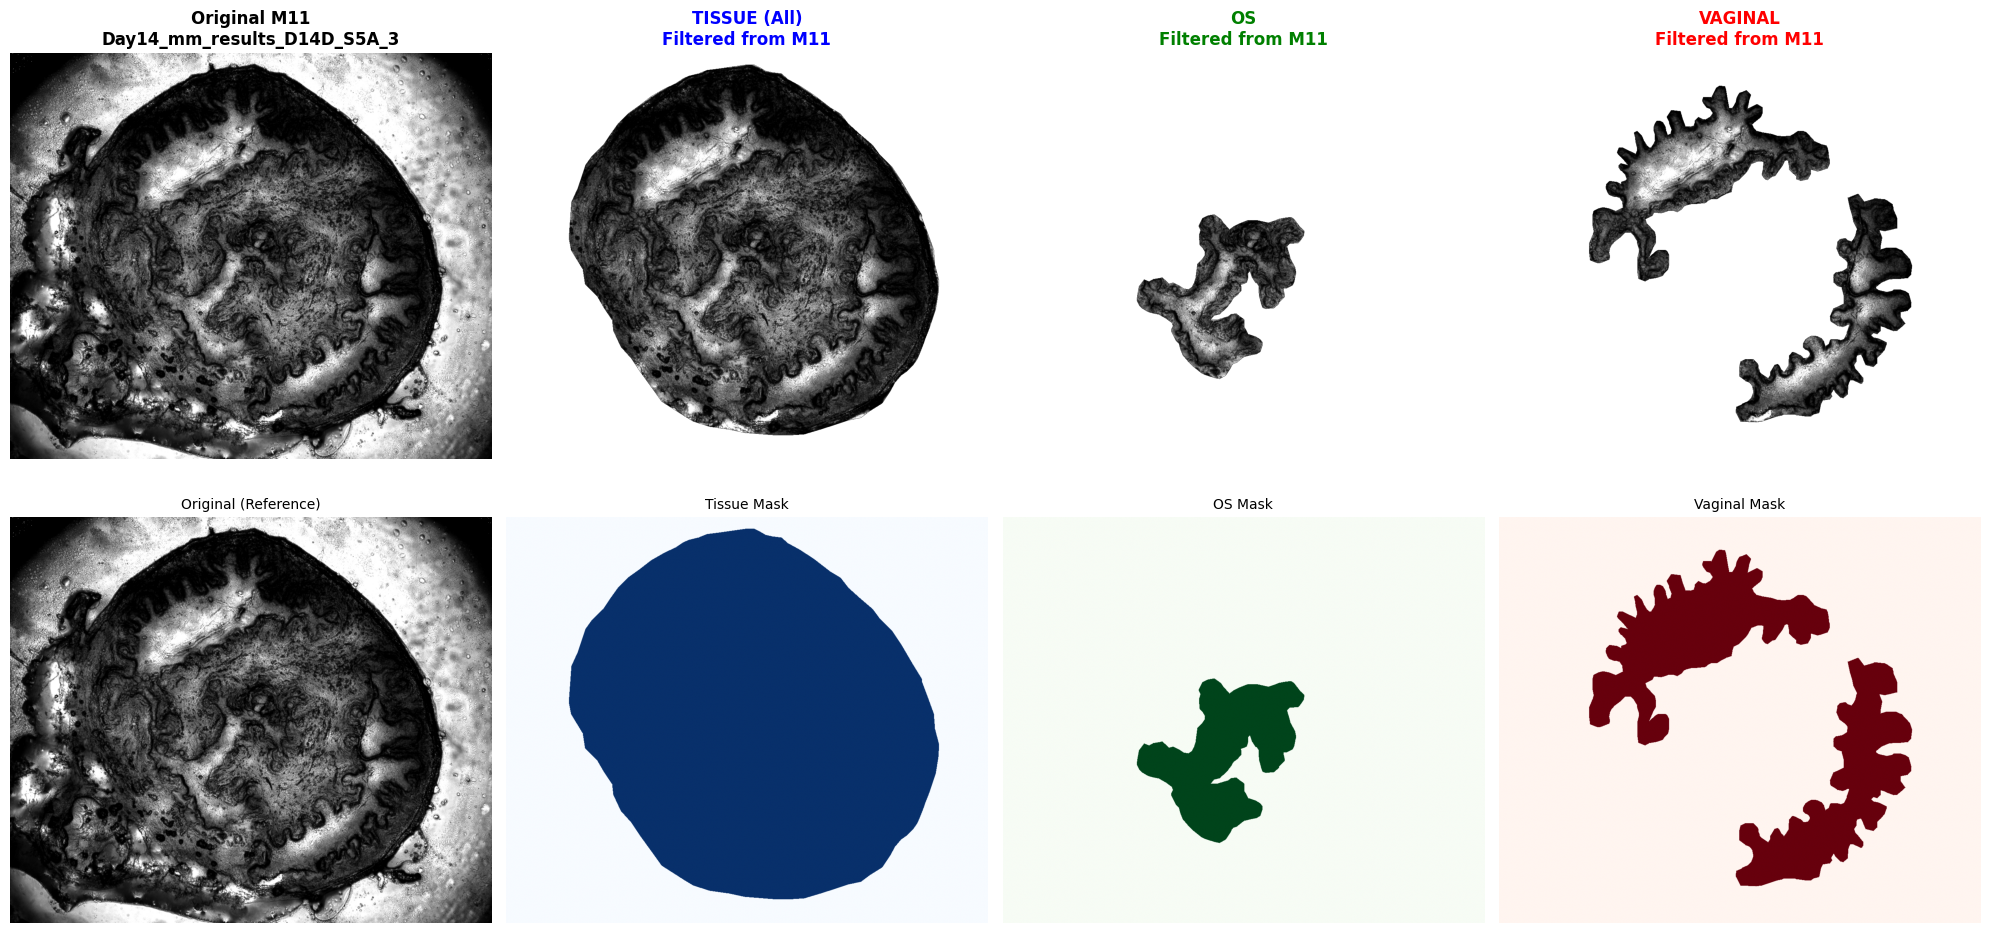


INDIVIDUAL TISSUE COMPONENT STATISTICS
Sample: Day14_mm_results_D14D_S5A_3

Component                      Pixels          Percentage      Mean M11       
--------------------------------------------------------------------------------
TISSUE (All)                   710871          51.60           0.2463         
  - Tissue only                391339          28.41           0.2146         
OS                             95150           6.91            0.2807         
VAGINAL                        224382          16.29           0.2872         
Background                     666813          48.40           -              
--------------------------------------------------------------------------------
TOTAL                          1377684         100.00         

VERIFICATION
Tissue-only + OS + Vaginal = 710871 pixels
Total Tissue (all) = 710871 pixels
Match: True

Visualization saved to: models\individual_tissue_components.png


In [18]:
# Extract individual masks from the combined mask
# mask contains: 0=Background, 1=Tissue, 2=OS, 3=Vaginal

# Create individual binary masks
tissue_only_mask = (mask == 1)  # Only tissue (not OS or Vaginal)
os_mask = (mask == 2)           # OS mask
vaginal_mask = (mask == 3)      # Vaginal mask
tissue_all_mask = (mask >= 1)   # All tissue (includes OS and Vaginal)

# Filter M11 image using each mask
m11_tissue_all = np.where(tissue_all_mask, m11, np.nan)
m11_tissue_only = np.where(tissue_only_mask, m11, np.nan)
m11_os = np.where(os_mask, m11, np.nan)
m11_vaginal = np.where(vaginal_mask, m11, np.nan)

# Create figure showing the three main components
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Row 1: Original and the three filtered components
axes[0, 0].imshow(m11, cmap='gray')
axes[0, 0].set_title(f'Original M11\n{sample_name}', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(m11_tissue_all, cmap='gray')
axes[0, 1].set_title('TISSUE (All)\nFiltered from M11', fontsize=12, fontweight='bold', color='blue')
axes[0, 1].axis('off')

axes[0, 2].imshow(m11_os, cmap='gray')
if os_mask.any():
    axes[0, 2].set_title('OS\nFiltered from M11', fontsize=12, fontweight='bold', color='green')
else:
    axes[0, 2].set_title('OS\n(No mask available)', fontsize=12, fontweight='bold', color='gray')
axes[0, 2].axis('off')

axes[0, 3].imshow(m11_vaginal, cmap='gray')
if vaginal_mask.any():
    axes[0, 3].set_title('VAGINAL\nFiltered from M11', fontsize=12, fontweight='bold', color='red')
else:
    axes[0, 3].set_title('VAGINAL\n(No mask available)', fontsize=12, fontweight='bold', color='gray')
axes[0, 3].axis('off')

# Row 2: Binary masks for reference
axes[1, 0].imshow(m11, cmap='gray')
axes[1, 0].set_title('Original (Reference)', fontsize=10)
axes[1, 0].axis('off')

axes[1, 1].imshow(tissue_all_mask, cmap='Blues', vmin=0, vmax=1)
axes[1, 1].set_title('Tissue Mask', fontsize=10)
axes[1, 1].axis('off')

axes[1, 2].imshow(os_mask, cmap='Greens', vmin=0, vmax=1)
axes[1, 2].set_title('OS Mask', fontsize=10)
axes[1, 2].axis('off')

axes[1, 3].imshow(vaginal_mask, cmap='Reds', vmin=0, vmax=1)
axes[1, 3].set_title('Vaginal Mask', fontsize=10)
axes[1, 3].axis('off')

plt.tight_layout()
plt.savefig(Config.OUTPUT_DIR / 'individual_tissue_components.png', dpi=150, bbox_inches='tight')
plt.show()

# Print statistics for each component
print(f"\n{'='*80}")
print("INDIVIDUAL TISSUE COMPONENT STATISTICS")
print(f"{'='*80}")
print(f"Sample: {sample_name}")
print(f"\n{'Component':<30} {'Pixels':<15} {'Percentage':<15} {'Mean M11':<15}")
print(f"{'-'*80}")

total_pixels = mask.size

# Tissue (all)
tissue_pixels = tissue_all_mask.sum()
tissue_pct = tissue_pixels / total_pixels * 100
tissue_mean = m11[tissue_all_mask].mean() if tissue_all_mask.any() else 0
print(f"{'TISSUE (All)':<30} {tissue_pixels:<15} {tissue_pct:<15.2f} {tissue_mean:<15.4f}")

# Tissue only (excluding OS/Vaginal)
tissue_only_pixels = tissue_only_mask.sum()
tissue_only_pct = tissue_only_pixels / total_pixels * 100
tissue_only_mean = m11[tissue_only_mask].mean() if tissue_only_mask.any() else 0
print(f"{'  - Tissue only':<30} {tissue_only_pixels:<15} {tissue_only_pct:<15.2f} {tissue_only_mean:<15.4f}")

# OS
os_pixels = os_mask.sum()
os_pct = os_pixels / total_pixels * 100
os_mean = m11[os_mask].mean() if os_mask.any() else 0
print(f"{'OS':<30} {os_pixels:<15} {os_pct:<15.2f} {os_mean:<15.4f}")

# Vaginal
vaginal_pixels = vaginal_mask.sum()
vaginal_pct = vaginal_pixels / total_pixels * 100
vaginal_mean = m11[vaginal_mask].mean() if vaginal_mask.any() else 0
print(f"{'VAGINAL':<30} {vaginal_pixels:<15} {vaginal_pct:<15.2f} {vaginal_mean:<15.4f}")

# Background
bg_pixels = (mask == 0).sum()
bg_pct = bg_pixels / total_pixels * 100
print(f"{'Background':<30} {bg_pixels:<15} {bg_pct:<15.2f} {'-':<15}")

print(f"{'-'*80}")
print(f"{'TOTAL':<30} {total_pixels:<15} {100.0:<15.2f}")

# Verify the composition
print(f"\n{'='*80}")
print("VERIFICATION")
print(f"{'='*80}")
print(f"Tissue-only + OS + Vaginal = {tissue_only_pixels + os_pixels + vaginal_pixels} pixels")
print(f"Total Tissue (all) = {tissue_pixels} pixels")
print(f"Match: {tissue_only_pixels + os_pixels + vaginal_pixels == tissue_pixels}")

print(f"\nVisualization saved to: {Config.OUTPUT_DIR / 'individual_tissue_components.png'}")
print(f"{'='*80}")

## 16. Visualize Individual Tissue Components

Visualize OS and Vaginal masks separately from the overall tissue mask.